In [223]:
# read soundfile
import librosa
from IPython.display import Audio
import matplotlib.pyplot as plt
import numpy as np

# Codigo: Descubrimiento de Unidades del Lenguaje

Vamos a tomar una grabación con dos personas hablando y vamos a segementar de forma automática a cada participante. Tomemos los primeros 3 minutos de la siguiente grabación:

[https://www.youtube.com/watch?v=2Xk0v1g3x4E](https://www.youtube.com/watch?v=2Xk0v1g3x4E)

Aproximandamente el primer hablante habla hasta el segundo 95 y el segundo hablante habla desde ahí en adelante.

In [224]:
sr = 16000
x,sr = librosa.load('../../assets/chomfuc.ogg', offset=0.78, duration=3*60, sr=sr)
print(f"Audio length: {len(x)/sr:.2f} seconds")
cambio = 95
Audio(x[int((cambio-3)*sr):int((cambio+3)*sr)], rate=sr) # 3 seconds of audio

/tmp/ipykernel_413289/1982307451.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  x,sr = librosa.load('../../assets/chomfuc.ogg', offset=0.78, duration=3*60, sr=sr)
/home/miles/miniconda3/envs/newbase/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Audio length: 180.00 seconds


Calculamos atributos a partir del audio con una ventana de 40ms y un paso de 20ms. Usaremos MFCC, delta y delta-delta. Luego aplicaremos un filtro de media movil de 100 puntos (2 segundos) para suavizar la señal ya que nos interesan los cambios lentos en la señal no las unidades cortas como fonemas.

In [232]:
from scipy.signal import lfilter

# mfcc, delta, delta-delta

win_length = int(0.04*sr)
hop_length = int(0.02*sr)
mfcc = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=20, n_fft=win_length, hop_length=hop_length)
delta_mfcc = librosa.feature.delta(mfcc)
delta2_mfcc = librosa.feature.delta(mfcc, order=2)
mfcc_concat = np.concatenate((mfcc, delta_mfcc, delta2_mfcc), axis=0)

n=80
mfcc_concat_filter = lfilter(b=np.ones(n)/n, a=1, x=mfcc_concat)[:, n-1:]

# Normalize
mfcc_norm = (mfcc_concat_filter - mfcc_concat_filter.mean(axis=1, keepdims=True)) / (mfcc_concat_filter.std(axis=1, keepdims=True) + 1e-10)

Visualizamos la matriz de atributos

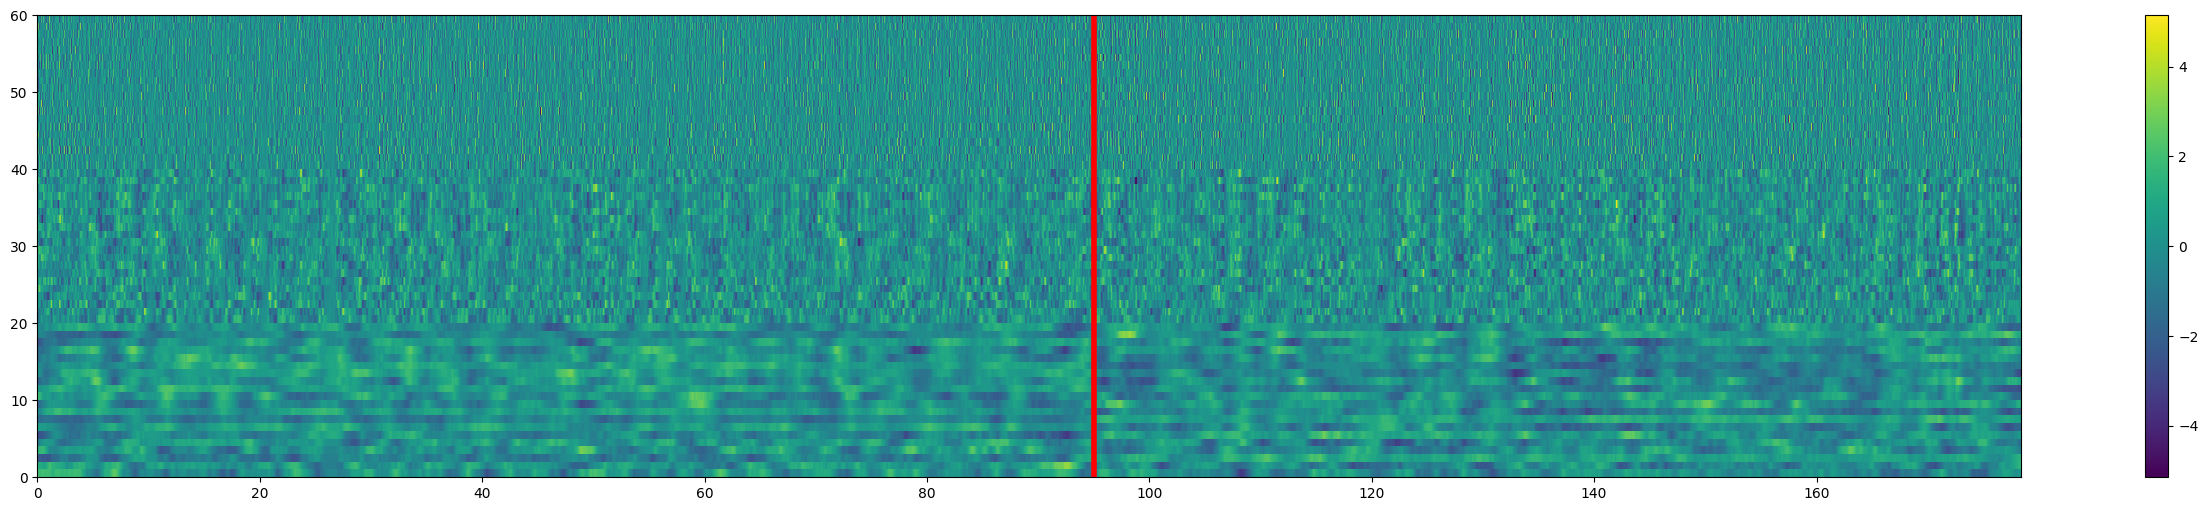

In [233]:
plt.figure(figsize=(32,6))
tiempos = librosa.frames_to_time(np.arange(mfcc_norm.shape[1]), sr=sr, hop_length=hop_length)
plt.imshow(mfcc_norm, aspect='auto', origin='lower', interpolation='none', extent=[tiempos[0], tiempos[-1], 0, mfcc_norm.shape[0]])
plt.colorbar();
plt.vlines(cambio, 0, mfcc_norm.shape[0], color='red', linestyle='-', lw=4);

Ahora probemos hacer aprendizae no supervisado con K-means directamente sobre los atributos. Si le pedimos 2 clusters, desaríamos que el primer cluster corresponda al primer hablante y el segundo cluster al segundo hablante.

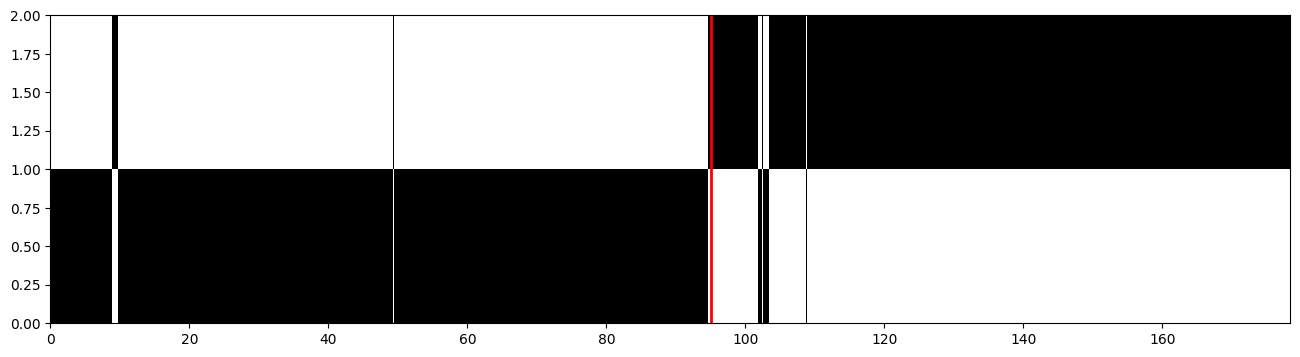

In [234]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(mfcc_norm.T)
labels = kmeans.predict(mfcc_norm.T)
# to onehot
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
labels = ohe.fit_transform(labels.reshape(-1,1)).todense().T
plt.figure(figsize=(16,4))
plt.imshow(labels, aspect='auto', origin='lower', interpolation='none',cmap='gray', extent=[tiempos[0], tiempos[-1], 0, labels.shape[0]]);
plt.vlines(cambio, 0, labels.shape[0], color='red', linestyle='-', lw=2);

Veamos la conversación entera en forma de matriz de similaridad. Deberíamos ver dos bloques de similaridad, uno para cada hablante.

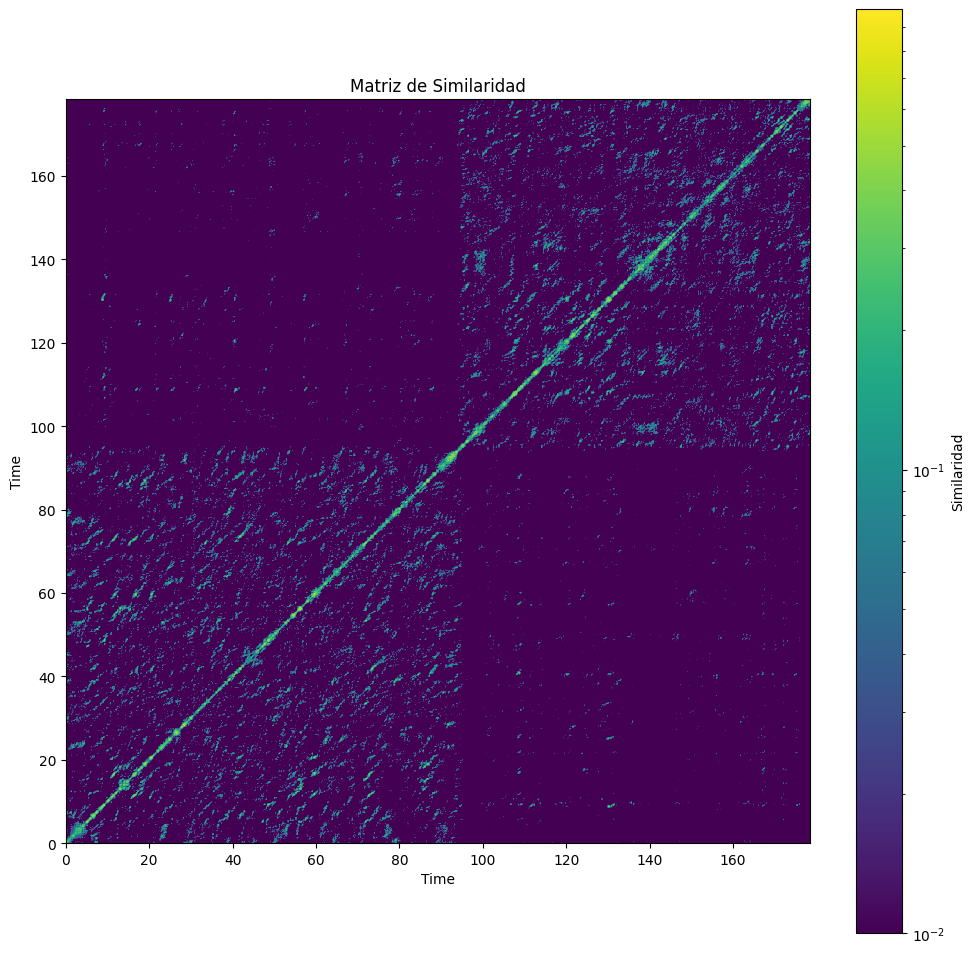

In [235]:
R = librosa.segment.recurrence_matrix(mfcc_norm, sym=True, metric='cosine', mode='affinity', width=1,  bandwidth=0.5)
plt.figure(figsize=(12,12))
# log norm colormap
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=0.01, vmax=R.max())
plt.imshow(R[::3,::3]+1e-10, aspect='auto', origin='lower', extent=[tiempos[0], tiempos[-1], tiempos[0], tiempos[-1]], cmap='viridis', norm=norm)
plt.gca().set_aspect('equal', adjustable='box')
cbar = plt.colorbar()
cbar.ax.set_ylabel('Similaridad')
plt.title('Matriz de Similaridad')
plt.xlabel('Time')
plt.ylabel('Time');

In [236]:
# # spectral clustering
# from sklearn.manifold import spectral_embedding

# D = spectral_embedding(R, n_components=20, drop_first=True)

# plt.figure(figsize=(16,4))
# plt.imshow(D.T, aspect='auto', origin='lower', interpolation='none');

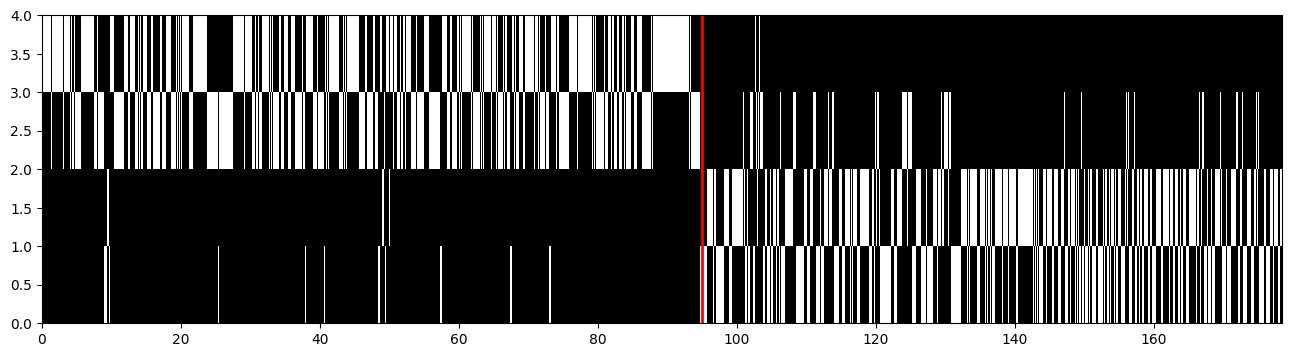

In [237]:
kmeans = KMeans(n_clusters=4, random_state=0).fit(mfcc_norm.T)
labels = kmeans.predict(mfcc_norm.T)
# to onehot
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
labels = ohe.fit_transform(labels.reshape(-1,1)).todense().T
plt.figure(figsize=(16,4))
plt.imshow(labels, aspect='auto', origin='lower', interpolation='none',cmap='gray', extent=[tiempos[0], tiempos[-1], 0, labels.shape[0]]);
plt.vlines(cambio, 0, labels.shape[0], color='red', linestyle='-', lw=2);

In [ ]:
for k in range(labels.shape[0]):
    frames = np.where(labels[k,:].T == 1)[0]
    X = librosa.util.frame(x, frame_length=win_length, hop_length=hop_length)

    X = X[:, frames]*np.hanning(win_length)[:, None]
    y = np.zeros(X.shape[1]*hop_length+win_length)
    for i in range(X.shape[1]):
        y[i*hop_length:i*hop_length+win_length] += X[:, i] 

    print("Cluster", k)
    display(Audio(y, rate=sr))

Cluster 0


Cluster 1


Cluster 2


Cluster 3
